In [161]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [162]:
pd.set_option('display.max_columns', None)   # show all columns
pd.set_option('display.width', None)  
df = pd.read_csv(r'R:\PROJECTS\Public_Transport_Delay_Prediction\public_transport_delays.csv')
df.head()

,trip_id,date,time,transport_type,route_id,origin_station,destination_station,scheduled_departure,scheduled_arrival,actual_departure_delay_min,actual_arrival_delay_min,weather_condition,temperature_C,humidity_percent,wind_speed_kmh,precipitation_mm,event_type,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,season,delayed
0,T00000,2023-01-01,05:00:00,Tram,Route_15,Station_31,Station_6,05:02:00,05:55:00,12,3,Storm,5.1,52,46,13.0,NaN,500,81,0,1,6,Winter,0
1,T00001,2023-01-01,05:15:00,Metro,Route_12,Station_49,Station_32,05:16:00,05:55:00,15,9,Rain,34.0,64,11,11.4,NaN,0,53,0,0,6,Autumn,1
2,T00002,2023-01-01,05:30:00,Bus,Route_16,Station_29,Station_42,05:33:00,06:17:00,0,0,Clear,29.5,35,31,14.1,Sports,0,67,1,0,6,Autumn,0
3,T00003,2023-01-01,05:45:00,Tram,Route_19,Station_26,Station_18,05:49:00,06:08:00,15,10,Clear,27.4,55,41,6.4,NaN,500,84,0,0,6,Winter,1
4,T00004,2023-01-01,06:00:00,Tram,Route_8,Station_18,Station_15,06:00:00,06:35:00,-1,14,Snow,0.1,90,30,18.5,NaN,500,46,0,0,6,Spring,1


In [163]:
df.columns

Index(['trip_id', 'date', 'time', 'transport_type', 'route_id',
       'origin_station', 'destination_station', 'scheduled_departure',
       'scheduled_arrival', 'actual_departure_delay_min',
       'actual_arrival_delay_min', 'weather_condition', 'temperature_C',
       'humidity_percent', 'wind_speed_kmh', 'precipitation_mm', 'event_type',
       'event_attendance_est', 'traffic_congestion_index', 'holiday',
       'peak_hour', 'weekday', 'season', 'delayed'],
      dtype='str')

In [164]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   trip_id                     2000 non-null   str    
 1   date                        2000 non-null   str    
 2   time                        2000 non-null   str    
 3   transport_type              2000 non-null   str    
 4   route_id                    2000 non-null   str    
 5   origin_station              2000 non-null   str    
 6   destination_station         2000 non-null   str    
 7   scheduled_departure         2000 non-null   str    
 8   scheduled_arrival           2000 non-null   str    
 9   actual_departure_delay_min  2000 non-null   int64  
 10  actual_arrival_delay_min    2000 non-null   int64  
 11  weather_condition           2000 non-null   str    
 12  temperature_C               2000 non-null   float64
 13  humidity_percent            2000 non-null   

In [165]:
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day

In [166]:
df['time'] = pd.to_datetime(df['time'], format='%H:%M:%S')
df['hour'] = pd.to_datetime(df['time'], format='%H:%M').dt.hour

In [167]:
df['scheduled_arrival'] = pd.to_datetime(df['scheduled_arrival'], format='%H:%M:%S')
df['scheduled_departure'] = pd.to_datetime(df['scheduled_departure'], format='%H:%M:%S')
df['scheduled_arrival_hour'] = pd.to_datetime(df['scheduled_arrival'], format='%H:%M').dt.hour
df['scheduled_departure_hour'] = pd.to_datetime(df['scheduled_departure'], format='%H:%M').dt.hour
df['scheduled_arrival_minute'] = pd.to_datetime(df['scheduled_arrival'], format='%H:%M').dt.minute
df['scheduled_departure_minute'] = pd.to_datetime(df['scheduled_departure'], format='%H:%M').dt.minute


In [168]:
df.isna().sum()


trip_id                          0
date                             0
time                             0
transport_type                   0
route_id                         0
origin_station                   0
destination_station              0
scheduled_departure              0
scheduled_arrival                0
actual_departure_delay_min       0
actual_arrival_delay_min         0
weather_condition                0
temperature_C                    0
humidity_percent                 0
wind_speed_kmh                   0
precipitation_mm                 0
event_type                    1173
event_attendance_est             0
traffic_congestion_index         0
holiday                          0
peak_hour                        0
weekday                          0
season                           0
delayed                          0
month                            0
day                              0
hour                             0
scheduled_arrival_hour           0
scheduled_departure_

In [169]:
df.duplicated().sum()

np.int64(0)

In [170]:
df['event_type'] = df['event_type'].fillna('No Event')

In [171]:
cal_col = df.select_dtypes(include=["object", "string"]).columns

print("Categorical Columns:", cal_col)

Categorical Columns: Index(['trip_id', 'transport_type', 'route_id', 'origin_station',
       'destination_station', 'weather_condition', 'event_type', 'season'],
      dtype='str')


In [172]:
num_col = df.select_dtypes(include=["int64", "float64"]).columns
#print("Numerical Columns:", num_col)
num_col = num_col.drop(['actual_arrival_delay_min','delayed','traffic_congestion_index','holiday','peak_hour','weekday'])

In [173]:
print('Before Scaling:')
df[num_col]

Before Scaling:


,actual_departure_delay_min,temperature_C,humidity_percent,wind_speed_kmh,precipitation_mm,event_attendance_est
0,12,5.1,52,46,13.0,500
1,15,34.0,64,11,11.4,0
2,0,29.5,35,31,14.1,0
3,15,27.4,55,41,6.4,500
4,-1,0.1,90,30,18.5,500
...,...,...,...,...,...,...
1995,15,17.2,98,35,4.6,0
1996,11,0.0,89,44,15.4,0
1997,1,12.9,95,32,2.7,0
1998,7,17.8,55,35,8.8,2000


In [174]:
X_train.columns

Index(['route_id', 'origin_station', 'destination_station',
       'actual_departure_delay_min', 'temperature_C', 'humidity_percent',
       'wind_speed_kmh', 'precipitation_mm', 'event_attendance_est',
       'traffic_congestion_index', 'holiday', 'peak_hour', 'weekday',
       'delayed', 'month', 'day', 'hour', 'scheduled_arrival_hour',
       'scheduled_departure_hour', 'scheduled_arrival_minute',
       'scheduled_departure_minute', 'transport_type_Metro',
       'transport_type_Train', 'transport_type_Tram',
       'weather_condition_Cloudy', 'weather_condition_Fog',
       'weather_condition_Rain', 'weather_condition_Snow',
       'weather_condition_Storm', 'event_type_Festival', 'event_type_No Event',
       'event_type_Parade', 'event_type_Protest', 'event_type_Sports',
       'season_Spring', 'season_Summer', 'season_Winter'],
      dtype='str')

In [175]:
df[cal_col]

,trip_id,transport_type,route_id,origin_station,destination_station,weather_condition,event_type,season
0,T00000,Tram,Route_15,Station_31,Station_6,Storm,No Event,Winter
1,T00001,Metro,Route_12,Station_49,Station_32,Rain,No Event,Autumn
2,T00002,Bus,Route_16,Station_29,Station_42,Clear,Sports,Autumn
3,T00003,Tram,Route_19,Station_26,Station_18,Clear,No Event,Winter
4,T00004,Tram,Route_8,Station_18,Station_15,Snow,No Event,Spring
...,...,...,...,...,...,...,...,...
1995,T01995,Bus,Route_11,Station_46,Station_39,Storm,No Event,Winter
1996,T01996,Train,Route_9,Station_44,Station_42,Snow,Festival,Winter
1997,T01997,Bus,Route_12,Station_4,Station_45,Snow,No Event,Summer
1998,T01998,Tram,Route_17,Station_29,Station_48,Clear,No Event,Summer


In [176]:
df = df.drop(columns=['trip_id', 'date', 'time','scheduled_arrival','scheduled_departure'])

In [177]:
low_cardinality = [
    'transport_type',
    'weather_condition',
    'event_type',
    'season'
]

high_cardinality = [
    'route_id',
    'origin_station',
    'destination_station'
]

df = pd.get_dummies(
    df,
    columns=low_cardinality,
    drop_first=True
)

le = LabelEncoder()

for col in high_cardinality:
    df[col] = le.fit_transform(df[col])

In [178]:
df.columns

Index(['route_id', 'origin_station', 'destination_station',
       'actual_departure_delay_min', 'actual_arrival_delay_min',
       'temperature_C', 'humidity_percent', 'wind_speed_kmh',
       'precipitation_mm', 'event_attendance_est', 'traffic_congestion_index',
       'holiday', 'peak_hour', 'weekday', 'delayed', 'month', 'day', 'hour',
       'scheduled_arrival_hour', 'scheduled_departure_hour',
       'scheduled_arrival_minute', 'scheduled_departure_minute',
       'transport_type_Metro', 'transport_type_Train', 'transport_type_Tram',
       'weather_condition_Cloudy', 'weather_condition_Fog',
       'weather_condition_Rain', 'weather_condition_Snow',
       'weather_condition_Storm', 'event_type_Festival', 'event_type_No Event',
       'event_type_Parade', 'event_type_Protest', 'event_type_Sports',
       'season_Spring', 'season_Summer', 'season_Winter'],
      dtype='str')

In [179]:
X = df.drop(columns=['actual_arrival_delay_min'])
y = df['actual_arrival_delay_min']
X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=42,test_size=0.2)

In [180]:
X_train['holiday']

968     0
240     0
819     0
692     0
420     0
       ..
1130    0
1294    0
860     0
1459    0
1126    0
Name: holiday, Length: 1600, dtype: int64

In [181]:
scaler = StandardScaler()
X_train[num_col] = scaler.fit_transform(X_train[num_col])
X_test[num_col] = scaler.transform(X_test[num_col])

In [182]:
rf_reg = RandomForestRegressor(n_estimators=100, random_state=40)

rf_reg.fit(X_train, y_train)
pred = rf_reg.predict(X_test)
pred

array([ 0.74, 17.53, 17.99,  1.22, 19.83,  0.3 , 17.21, 16.18, 15.59,
       16.37,  1.26, 18.46,  1.15, 17.43,  1.39,  2.  ,  0.61, 17.86,
       16.77, 18.24,  1.74,  1.41, 17.79, 16.85, 15.99,  1.43, 18.04,
       18.86,  2.37,  1.03, 16.9 , 17.38,  1.58,  1.31, 18.98, 19.03,
       16.06, 17.61, 18.19, 16.05,  1.81, -0.24, 18.43, 17.05, 18.16,
       20.04, 18.58, 17.93, 16.01,  0.73, 19.6 , 15.28,  2.46, 19.55,
       17.29, 16.81, 17.98, 16.75,  0.62, 13.38,  0.94,  1.4 , 18.44,
       14.66, 17.18,  1.17,  1.6 , 15.77, 18.64,  1.48, 17.02, 16.02,
       16.35, 16.7 , 16.25, 19.68, 15.36,  1.4 ,  1.92, 20.34, 16.54,
       16.29, 18.23,  1.64, 17.24, 21.58, 16.15,  1.94, 17.11,  1.29,
       19.11, 18.34, 15.53, 18.1 , 17.67,  0.99,  2.15, 17.1 , 17.7 ,
       17.64, 17.09, 16.99,  1.78,  0.59, 16.48,  0.68, 18.91,  1.24,
       18.08, 17.63, 18.71, 14.72,  2.12, 17.55, 15.09,  1.19,  1.97,
       17.88, 18.87, 16.06, 17.62, 17.54, 16.05, 16.92,  1.79,  0.48,
       20.59, 17.28,

In [183]:
print("Mean Squared Error:", mean_squared_error(y_test, pred))
print("R-squared:", r2_score(y_test, pred))

Mean Squared Error: 33.5116545
R-squared: 0.6025411382524593


In [184]:
cv_scores = cross_val_score(rf_reg, X, y, cv=5, scoring='r2')
mean_cv_score = cv_scores.mean()
print("Cross-Validation R-squared Scores:", mean_cv_score)

Cross-Validation R-squared Scores: 0.5684016327782178


In [185]:
X_train.tail(1)

,route_id,origin_station,destination_station,actual_departure_delay_min,temperature_C,humidity_percent,wind_speed_kmh,precipitation_mm,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,delayed,month,day,hour,scheduled_arrival_hour,scheduled_departure_hour,scheduled_arrival_minute,scheduled_departure_minute,transport_type_Metro,transport_type_Train,transport_type_Tram,weather_condition_Cloudy,weather_condition_Fog,weather_condition_Rain,weather_condition_Snow,weather_condition_Storm,event_type_Festival,event_type_No Event,event_type_Parade,event_type_Protest,event_type_Sports,season_Spring,season_Summer,season_Winter
1126,17,30,27,0.522387,0.213947,-0.180199,-1.60271,0.781362,-0.433186,57,0,0,3,1,1,12,22,22,22,54,32,True,False,False,False,False,False,True,False,False,True,False,False,False,True,False,False


In [186]:
df.iloc[1126]

route_id                         17
origin_station                   30
destination_station              27
actual_departure_delay_min       12
actual_arrival_delay_min         21
temperature_C                  17.6
humidity_percent                 61
wind_speed_kmh                    2
precipitation_mm               14.4
event_attendance_est              0
traffic_congestion_index         57
holiday                           0
peak_hour                         0
weekday                           3
delayed                           1
month                             1
day                              12
hour                             22
scheduled_arrival_hour           22
scheduled_departure_hour         22
scheduled_arrival_minute         54
scheduled_departure_minute       32
transport_type_Metro           True
transport_type_Train          False
transport_type_Tram           False
weather_condition_Cloudy      False
weather_condition_Fog         False
weather_condition_Rain      

In [187]:
new_row = {
    'route_id': [17],
    'origin_station': [30],
    'destination_station': [27],
    'actual_departure_delay_min': [0.522387],
    'temperature_C': [0.213947],
    'humidity_percent': [-0.180199],
    'wind_speed_kmh': [-1.602710],
    'precipitation_mm': [0.80],
    'event_attendance_est': [-0.5],
    'traffic_congestion_index': [57],
    'holiday': [0],
    'peak_hour': [0],
    'weekday': [3],
    'delayed': [1],
    'month': [1],
    'day': [12],
    'hour': [22],
    'scheduled_arrival_hour': [22],
    'scheduled_departure_hour': [22],
    'scheduled_arrival_minute': [54],
    'scheduled_departure_minute': [32],
    'transport_type_Metro': [1],
    'transport_type_Train': [0],
    'transport_type_Tram': [0],
    'weather_condition_Cloudy': [0],
    'weather_condition_Fog': [0],
    'weather_condition_Rain': [0],
    'weather_condition_Snow': [1],
    'weather_condition_Storm': [0],
    'event_type_Festival': [0],
    'event_type_No Event': [1],
    'event_type_Parade': [0],
    'event_type_Protest': [0],
    'event_type_Sports': [0],
    'season_Spring': [1],
    'season_Summer': [0],
    'season_Winter': [0]
}

# Convert to DataFrame
unseen_df = pd.DataFrame(new_row)


In [188]:
unseen_df[num_col] = scaler.transform(unseen_df[num_col])


In [189]:
prediction = rf_reg.predict(unseen_df)
print("Predicted arrival delay (minutes):", prediction[0])


Predicted arrival delay (minutes): 17.65


In [195]:
feature_importances = pd.DataFrame(rf_reg.feature_importances_, index=X_train.columns, columns=['importance']).sort_values('importance', ascending=False)
feature_importances



,importance
delayed,0.571097
temperature_C,0.032490
precipitation_mm,0.030664
humidity_percent,0.029884
scheduled_arrival_minute,0.029634
traffic_congestion_index,0.029606
origin_station,0.028933
wind_speed_kmh,0.027579
destination_station,0.026987
actual_departure_delay_min,0.022239


<Axes: title={'center': 'Feature Importances'}>

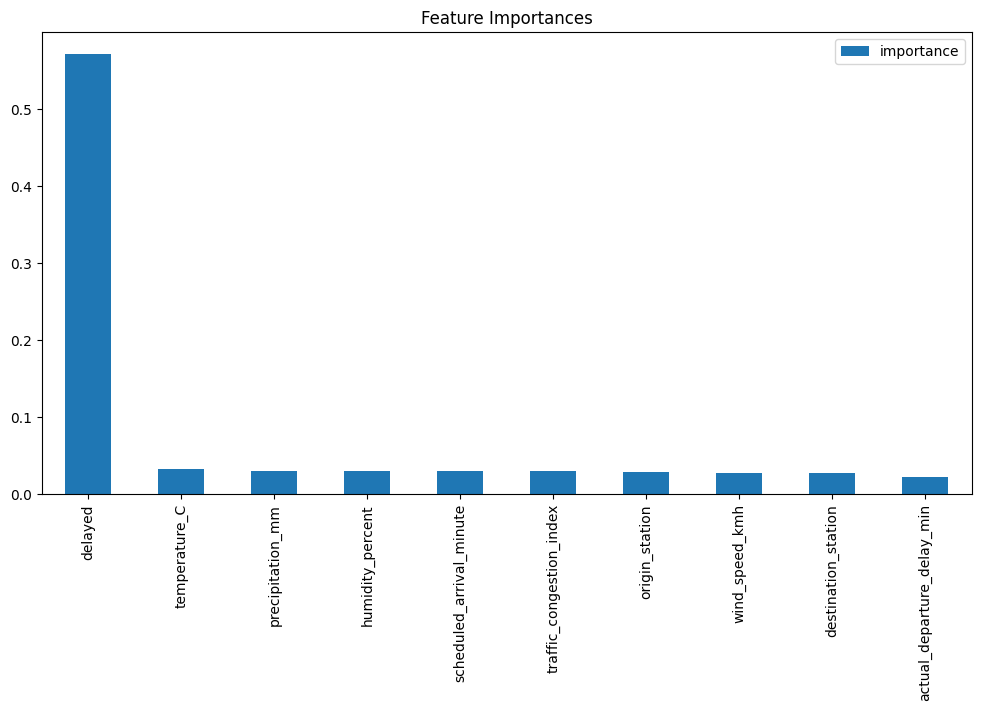

In [ ]:
feature_importances.head(10).plot(kind='bar', figsize=(12, 6), title='Feature Importances')
